# Analysis of nuclide and flux relaxation in RM schemes

In [ ]:
import CustomSchemes
from CustomSchemes import SIE
from CustomSchemes.SIE import load_SIE as load_SIE
import matplotlib.pyplot as plt

In [ ]:
the_file = SIE.SIE().get_from_pkl("FLUX.pkl")

In [ ]:
the_file.plot_all_x()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_x_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_fx_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
the_file.x[0.0][0]


# Anderson Acceleration analysis

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
import matplotlib.pyplot as plt
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')

In [ ]:
time = 3.0
for this in aa.fx[time]:
  plt.plot(this)

In [ ]:
aa.get

In [ ]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=3.0, file='aa2_i4_t3.pkl', k_max=4, m=2, dpi=100)

# Visual comparison of each

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')
flux = SIE().get_from_pkl('FLUX.pkl')
nuclide = SIE().get_from_pkl('NUCLIDE.pkl')


In [ ]:
def difference(x, ref) -> np.ndarray:
  return np.array([1-x[idx]/ref[idx] for idx in range(len(ref))])

time = 0.5
plt.figure(figsize=(5,3), dpi=250)
plt.plot(flux.x[time][-1], 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(nuclide.x[time][-1], 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(aa.x[time][-1], 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()

time = 0.5
ref = flux.x[time][-1]
aa_x = aa.x[time][-1]
nuc_x = nuclide.x[time][-1]

plt.figure(figsize=(5,3), dpi=250)
plt.plot(difference(ref, ref), 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(difference(nuc_x, ref), 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(difference(aa_x, ref), 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()


# Results for a single step

In [5]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import matplotlib.pyplot as plt
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i100_t2.pkl')
aaScaling = Anderson().get_from_pkl('aa2_scaling1.5_1step.pkl')
aaScaling2 = Anderson().get_from_pkl('aa2_i11_t2_2x.pkl')


from CustomSchemes.DumbTransport import flat_transport

x = aa.get_x_by_iteration(time=325.0)

Text(0.5, 0, 'Iteration')

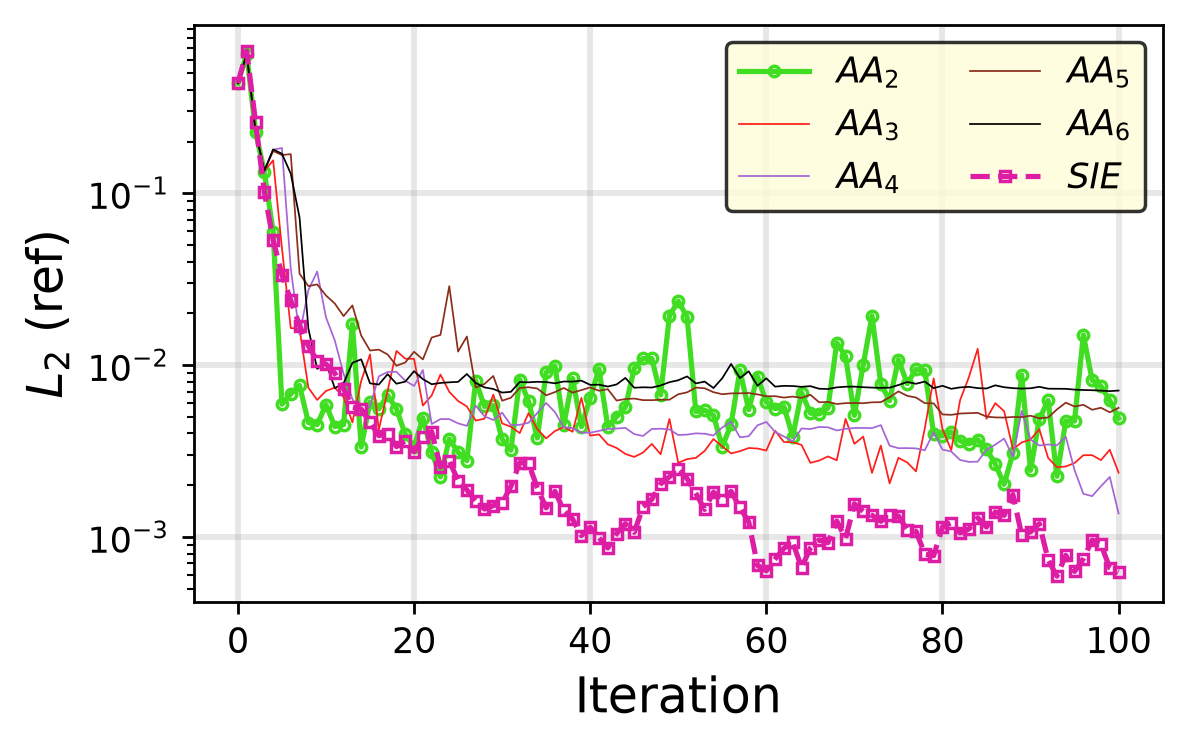

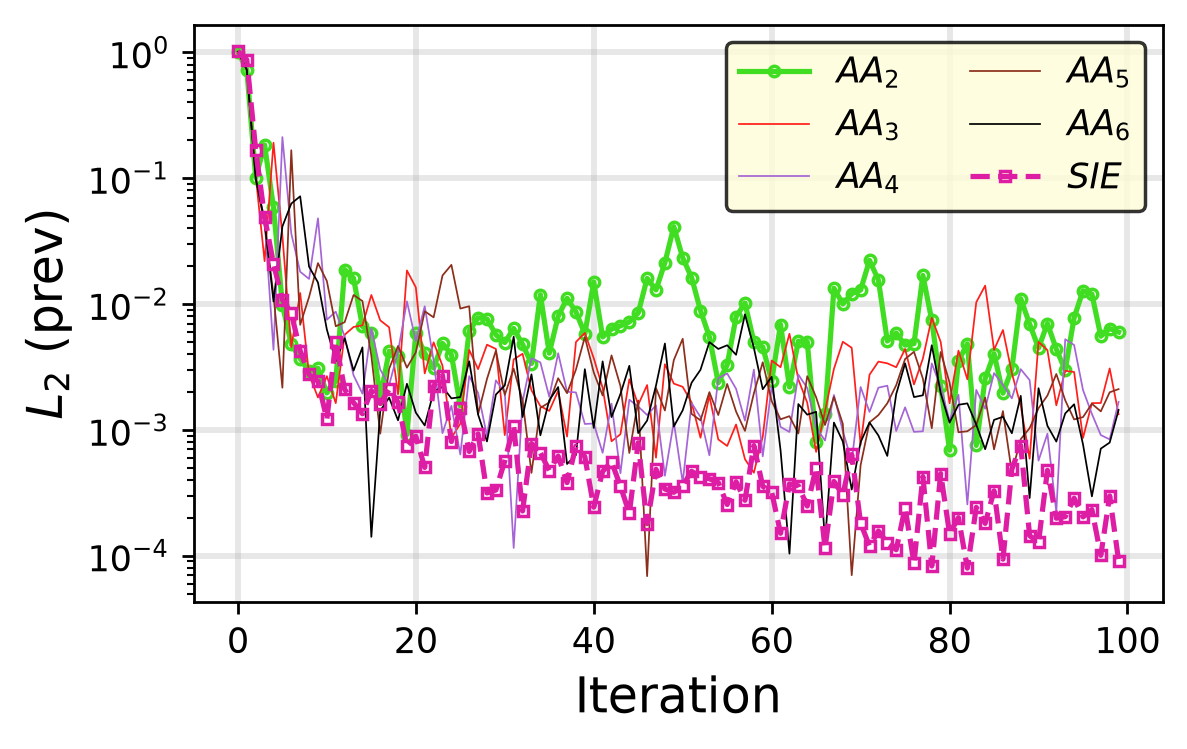

In [98]:
def get_norm(x: np.ndarray, xref: np.ndarray, order: int = 2) -> float:
  """gets the norm with the given order (default 2)"""
  return (np.linalg.norm(x - xref, ord=order)/np.linalg.norm(x, ord=order))

def get_all_norms_prev(x: list[np.ndarray], **kwargs):
  """get norms using previous solution"""
  resids_x = []
  npg = 0
  solve_np = 100000*500 # number active particles in each iteration
  x_old = x[0]
  x = x[1:]
  while len(x) > 0:
    resids_x.append(get_norm(x=x[0], xref=x_old))
    x_old = x[0]
    x = x[1:]
  return resids_x

def get_all_norms(x: list[np.ndarray], ref: np.ndarray):
  """get norms using a known reference solution"""
  resids_x = []
  npg = 0
  solve_np=100000*500
  for idx, this in enumerate(x):
    resids_x.append(get_norm(this, ref))
    total_histories.append(npg)
    try:
      npg+=solve_np
    except:
      npg += 0
  return resids_x

def particles_from_npg(time: float, aa: Anderson, nactive: int):
  """gets cumulative particles from NPG variable"""
  # for anderson, the first x() soln is always the predictor, which requires no NPG to get
  assert isinstance(aa, Anderson), "aa is not type Anderson"
  npg = 0
  npgvec = aa._npg[time]
  assert npgvec is not None, "npg vec is None, "
  new = [npg]
  for this in npgvec:
    new.append(new[-1] + this*nactive)

  assert len(new) == len(aa.x[time])
  return new

def particles_from_steps(time: float, aa: Anderson | SIE, nactive: int, npg: int):
  """used when you have a constant particles per step (not increasing hisstories withn more iterates)"""
  if isinstance(aa, Anderson):
    return _aa_particles_from_steps(time=time, aa=aa, nactive=nactive, npg=npg)
  elif isinstance(aa, SIE):
    return _sie_particles_from_steps(time=time, sie=aa, nactive=nactive, npg=npg)
  else:
    raise Exception("Not Anderson or SIE -- we dont know what to do!")

def _aa_particles_from_steps(time: float, aa: Anderson, nactive: int, npg: int):
  """aa uses x[0] as the predictor which means no particles are required"""
  return np.linspace(0,npg*nactive*(len(aa.x[time])-1), len(aa.x[time]))

def _sie_particles_from_steps(time: float, sie: SIE, nactive: int, npg: int):
  """sie uses x[0] as an actual solve, so we start at a nonzero number"""
  return np.linspace(npg*nactive,npg*nactive*(len(sie.x[time])), len(sie.x[time]))

aa2 = Anderson().get_from_pkl('aaN_1step/aa2_i100_t2.pkl')
aa3 = Anderson().get_from_pkl('aaN_1step/aa3_i100_t2.pkl')
aa4 = Anderson().get_from_pkl('aaN_1step/aa4_i100_t2.pkl')
aa5 = Anderson().get_from_pkl('aaN_1step/aa5_i100_t2.pkl')
aa6 = Anderson().get_from_pkl('aaN_1step/aa6_i100_t2.pkl')
sie = SIE().get_from_pkl('aaN_1step/sie_i99_t2.pkl')

r2 = get_all_norms(aa2.x[325], ref=flat_transport(16))
r3 = get_all_norms(aa3.x[325], ref=flat_transport(16))
r4 = get_all_norms(aa4.x[325], ref=flat_transport(16))
r5 = get_all_norms(aa5.x[325], ref=flat_transport(16))
r6 = get_all_norms(aa6.x[325], ref=flat_transport(16))
rS = get_all_norms(sie.x[325], ref=flat_transport(16))  

plt.figure(figsize=(5,3), dpi=250)
plt.plot(r2, 'o-', color=clrs[2], label=r"$AA_2$", markerfacecolor='none', markersize=3)
plt.plot(r3, color=clrs[3], label=r"$AA_3$", lw=0.5)
plt.plot(r4, color=clrs[4], label=r"$AA_4$", lw=0.5)
plt.plot(r5, color=clrs[5], label=r"$AA_5$", lw=0.5)
plt.plot(r6, color=clrs[6], label=r"$AA_6$", lw=0.5)
plt.plot(rS, 's--', color=clrs[7], label=r"$SIE$", markerfacecolor='none', markersize=3)
# plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')
plt.yscale('log')
# plt.xscale('log')
nice_grid(), nice_legend(ncols=2)
plt.ylabel(r'$L_2$ (ref)', fontsize=14)
plt.xlabel(r'Iteration', fontsize=14)

r2 = get_all_norms_prev(aa2.x[325])
r3 = get_all_norms_prev(aa3.x[325])
r4 = get_all_norms_prev(aa4.x[325])
r5 = get_all_norms_prev(aa5.x[325])
r6 = get_all_norms_prev(aa6.x[325])
rS = get_all_norms_prev(sie.x[325])  

plt.figure(figsize=(5,3), dpi=250)
plt.plot(r2, 'o-', color=clrs[2], label=r"$AA_2$", markerfacecolor='none', markersize=3)
plt.plot(r3, color=clrs[3], label=r"$AA_3$", lw=0.5)
plt.plot(r4, color=clrs[4], label=r"$AA_4$", lw=0.5)
plt.plot(r5, color=clrs[5], label=r"$AA_5$", lw=0.5)
plt.plot(r6, color=clrs[6], label=r"$AA_6$", lw=0.5)
plt.plot(rS, 's--', color=clrs[7], label=r"$SIE$", markerfacecolor='none', markersize=3)
# plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')
plt.yscale('log')
# plt.xscale('log')
nice_grid(), nice_legend(ncols=2)
plt.ylabel(r'$L_2$ (prev)', fontsize=14)
plt.xlabel(r'Iteration', fontsize=14)

/var/folders/gt/15kcq_g95yv3l_cjch6ybnzh0000gp/T/ipykernel_91848/2027951217.py:44: RuntimeWarning: divide by zero encountered in divide
  plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')


(None, None)

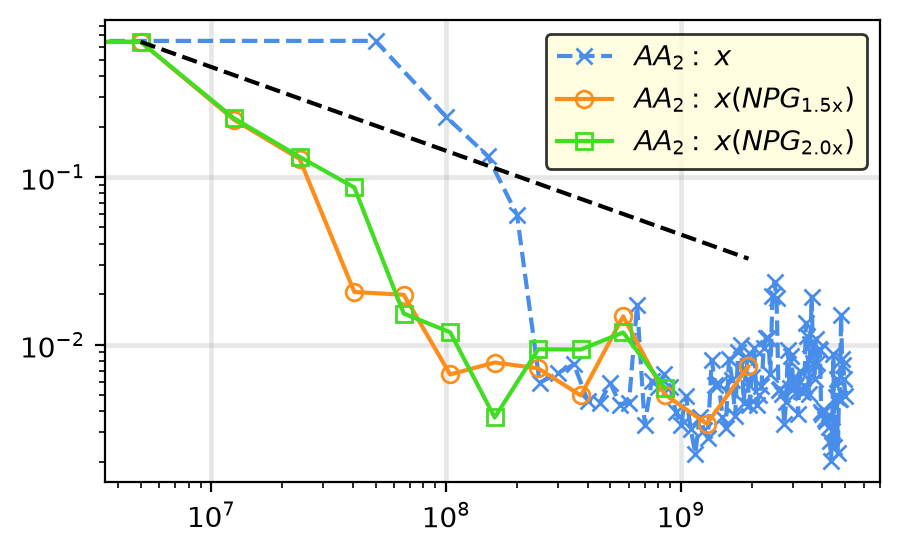

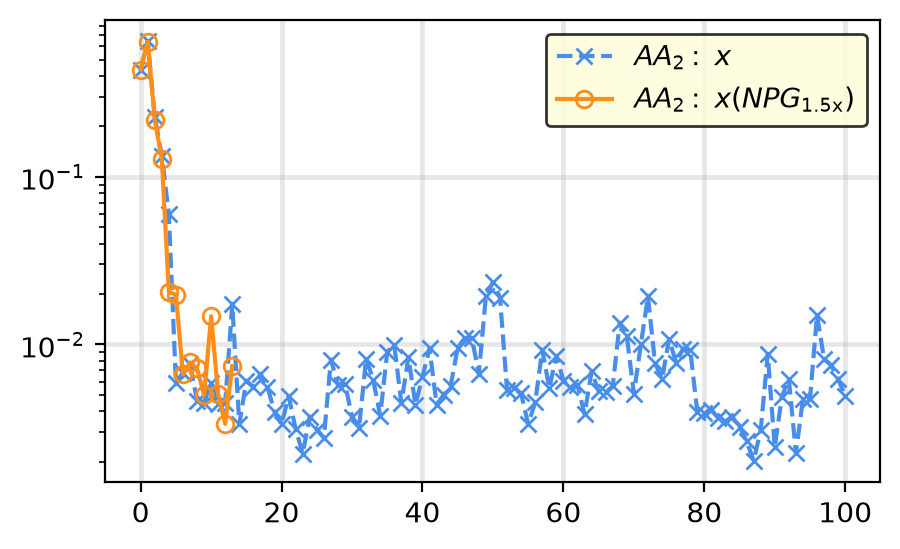

In [40]:

ref = flat_transport(16)
x = aa.get_x_by_iteration(time=325.0)
fx = aa.get_fx_by_iteration(time=325.0)
xscaling = aaScaling.get_x_by_iteration(time=325.0)
xscaling2 =aaScaling2.get_x_by_iteration(time=325.0)


resids_x = []
resids_fx = []
resids_xscaling = []
resids_xscaling2 = []
total_histories = []


npg = 0
for idx, this in enumerate(x):
  resids_x.append(get_norm(this, ref))
  total_histories.append(npg)
  try:
    npg+=100000*500
  except:
    npg += 0

npg = 0
histories_scaling = [0]
for idx, this in enumerate(xscaling):
  resids_xscaling.append(get_norm(this, ref))
for idx, this in enumerate(aaScaling._npg[325]):
  histories_scaling.append(histories_scaling[-1] + aaScaling._npg[325.0][idx]*500)

npg = 0
histories_scaling2 = [0]
for idx, this in enumerate(xscaling2):
  resids_xscaling2.append(get_norm(this, ref))
for idx, this in enumerate(aaScaling2._npg[325]):
  histories_scaling2.append(histories_scaling2[-1] + aaScaling2._npg[325.0][idx]*500)


plt.figure(figsize=(5,3), dpi=200)
plt.plot(total_histories, resids_x, 'x--', label=r'$AA_2:$ $x$', markerfacecolor='none', color=Colors.colors2()[0])
# plt.plot(total_histories, resids_fx, 'kx--', label=r'$AA2:$ $f(x)$')
plt.plot(histories_scaling,resids_xscaling , 'o-', label=r'$AA_2:$ $x(NPG_{1.5\mathrm{x}})$', markerfacecolor='none', color=Colors.colors2()[1])
plt.plot(histories_scaling2,resids_xscaling2 , 's-', label=r'$AA_2:$ $x(NPG_{2.0\mathrm{x}})$', markerfacecolor='none', color=Colors.colors2()[2])
plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend()




plt.figure(figsize=(5,3), dpi=200)
plt.plot(resids_x, 'x--', label=r'$AA_2:$ $x$', markerfacecolor='none', color=Colors.colors2()[0])
# plt.plot(total_histories, resids_fx, 'kx--', label=r'$AA2:$ $f(x)$')
plt.plot(resids_xscaling , 'o-', label=r'$AA_2:$ $x(NPG_{1.5\mathrm{x}})$', markerfacecolor='none', color=Colors.colors2()[1])
plt.yscale('log')
# plt.xscale('log')
nice_grid(), nice_legend()

Text(0.5, 0, 'Total active histories')

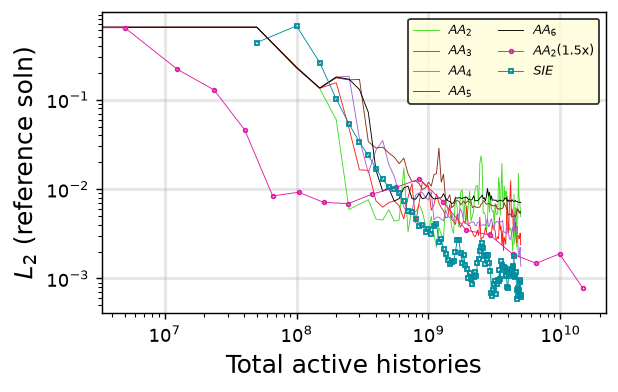

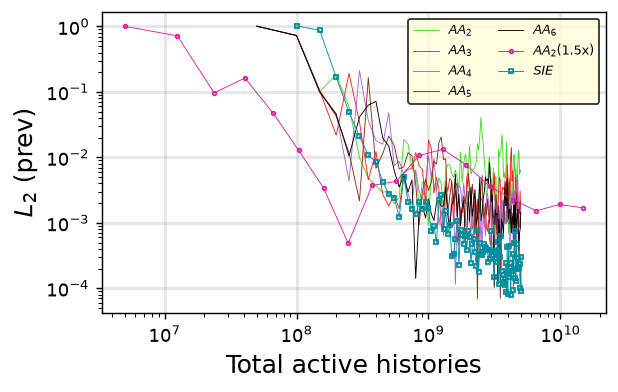

In [107]:

"""
Plotting the L2 against the reference solution
"""
# Get the cases
aa2 = Anderson().get_from_pkl('aaN_1step/aa2_i100_t2.pkl')
aa3 = Anderson().get_from_pkl('aaN_1step/aa3_i100_t2.pkl')
aa4 = Anderson().get_from_pkl('aaN_1step/aa4_i100_t2.pkl')
aa5 = Anderson().get_from_pkl('aaN_1step/aa5_i100_t2.pkl')
aa6 = Anderson().get_from_pkl('aaN_1step/aa6_i100_t2.pkl')
aa2_scaling_15 = Anderson().get_from_pkl('aaN_1step/aa2_i18_t2_1.5.pkl')
sie = SIE().get_from_pkl('aaN_1step/sie_i99_t2.pkl')

nactive = 500
npg = 100000
time=325

aa2_particles = particles_from_steps(time=time, aa=aa2, nactive=nactive, npg=npg)
aa3_particles = particles_from_steps(time=time, aa=aa3, nactive=nactive, npg=npg)
aa4_particles = particles_from_steps(time=time, aa=aa4, nactive=nactive, npg=npg)
aa5_particles = particles_from_steps(time=time, aa=aa5, nactive=nactive, npg=npg)
aa6_particles = particles_from_steps(time=time, aa=aa6, nactive=nactive, npg=npg)
aa2_scaling_15_particles = particles_from_npg(time=time, aa=aa2_scaling_15, nactive=nactive)
sie_particles = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)

aa2_norms = get_all_norms(x=aa2.x[time], ref=flat_transport(16))
aa3_norms = get_all_norms(x=aa3.x[time], ref=flat_transport(16))
aa4_norms = get_all_norms(x=aa4.x[time], ref=flat_transport(16))
aa5_norms = get_all_norms(x=aa5.x[time], ref=flat_transport(16))
aa6_norms = get_all_norms(x=aa6.x[time], ref=flat_transport(16))
aa2_scaling_15_norms = get_all_norms(x=aa2_scaling_15.x[time], ref=flat_transport(16))
sie_norms = get_all_norms(x=sie.x[time], ref=flat_transport(16))


plt.figure(figsize=(5,3), dpi=130)
plt.plot(aa2_particles, aa2_norms, '-', lw=0.5, color=clrs[2], label=r'$AA_2$', markerfacecolor='none', markersize=2)
plt.plot(aa3_particles, aa3_norms, '-', lw=0.5, color=clrs[3], label=r'$AA_3$', markerfacecolor='none', markersize=2)
plt.plot(aa4_particles, aa4_norms, '-', lw=0.5, color=clrs[4], label=r'$AA_4$', markerfacecolor='none', markersize=2)
plt.plot(aa5_particles, aa5_norms, '-', lw=0.5, color=clrs[5], label=r'$AA_5$', markerfacecolor='none', markersize=2)
plt.plot(aa6_particles, aa6_norms, '-', lw=0.5, color=clrs[6], label=r'$AA_6$', markerfacecolor='none', markersize=2)
plt.plot(aa2_scaling_15_particles, aa2_scaling_15_norms, 'o-', lw=0.5, color=clrs[7], label=r'$AA_2(1.5\mathrm{x})$', markerfacecolor='none', markersize=2)
plt.plot(sie_particles, sie_norms, 's-', lw=0.5, color=clrs[8], label=r'$SIE$', markerfacecolor='none', markersize=2)


plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (reference soln)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)


"""
Plotting the L2 against the previous solution
"""
# Get the cases
aa2 = Anderson().get_from_pkl('aaN_1step/aa2_i100_t2.pkl')
aa3 = Anderson().get_from_pkl('aaN_1step/aa3_i100_t2.pkl')
aa4 = Anderson().get_from_pkl('aaN_1step/aa4_i100_t2.pkl')
aa5 = Anderson().get_from_pkl('aaN_1step/aa5_i100_t2.pkl')
aa6 = Anderson().get_from_pkl('aaN_1step/aa6_i100_t2.pkl')
aa2_scaling_15 = Anderson().get_from_pkl('aaN_1step/aa2_i18_t2_1.5.pkl')
sie = SIE().get_from_pkl('aaN_1step/sie_i99_t2.pkl')

nactive = 500
npg = 100000
time=325

aa2_particles = particles_from_steps(time=time, aa=aa2, nactive=nactive, npg=npg)
aa3_particles = particles_from_steps(time=time, aa=aa3, nactive=nactive, npg=npg)
aa4_particles = particles_from_steps(time=time, aa=aa4, nactive=nactive, npg=npg)
aa5_particles = particles_from_steps(time=time, aa=aa5, nactive=nactive, npg=npg)
aa6_particles = particles_from_steps(time=time, aa=aa6, nactive=nactive, npg=npg)
aa2_scaling_15_particles = particles_from_npg(time=time, aa=aa2_scaling_15, nactive=nactive)
sie_particles = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)

aa2_norms = get_all_norms_prev(x=aa2.x[time], ref=flat_transport(16))
aa3_norms = get_all_norms_prev(x=aa3.x[time], ref=flat_transport(16))
aa4_norms = get_all_norms_prev(x=aa4.x[time], ref=flat_transport(16))
aa5_norms = get_all_norms_prev(x=aa5.x[time], ref=flat_transport(16))
aa6_norms = get_all_norms_prev(x=aa6.x[time], ref=flat_transport(16))
aa2_scaling_15_norms = get_all_norms_prev(x=aa2_scaling_15.x[time], ref=flat_transport(16))
sie_norms = get_all_norms_prev(x=sie.x[time], ref=flat_transport(16))


plt.figure(figsize=(5,3), dpi=130)
plt.plot(aa2_particles[1:], aa2_norms, '-', lw=0.5, color=clrs[2], label=r'$AA_2$', markerfacecolor='none', markersize=2)
plt.plot(aa3_particles[1:], aa3_norms, '-', lw=0.5, color=clrs[3], label=r'$AA_3$', markerfacecolor='none', markersize=2)
plt.plot(aa4_particles[1:], aa4_norms, '-', lw=0.5, color=clrs[4], label=r'$AA_4$', markerfacecolor='none', markersize=2)
plt.plot(aa5_particles[1:], aa5_norms, '-', lw=0.5, color=clrs[5], label=r'$AA_5$', markerfacecolor='none', markersize=2)
plt.plot(aa6_particles[1:], aa6_norms, '-', lw=0.5, color=clrs[6], label=r'$AA_6$', markerfacecolor='none', markersize=2)
plt.plot(aa2_scaling_15_particles[1:], aa2_scaling_15_norms, 'o-', lw=0.5, color=clrs[7], label=r'$AA_2(1.5\mathrm{x})$', markerfacecolor='none', markersize=2)
plt.plot(sie_particles[1:], sie_norms, 's-', lw=0.5, color=clrs[8], label=r'$SIE$', markerfacecolor='none', markersize=2)


plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend(ncols=2, fontsize=7)
plt.ylabel(r'$L_2$ (prev)', fontsize=14)
plt.xlabel(r'Total active histories', fontsize=14)

In [52]:
len(aa2_scaling_15.x[325])

14

In [55]:


particles_from_npg(time=325, aa=aa2_scaling_15, nactive=500)


[0,
 5000000,
 12500000,
 23750000,
 40625000,
 65937500,
 103906500,
 160860000,
 246290000,
 374435000,
 566652500,
 854978500,
 1287467500,
 1936201000]

In [62]:
np.linspace(0,100*(len(aa2.x[325])-1), len(aa2.x[325]))

array([    0.,   100.,   200.,   300.,   400.,   500.,   600.,   700.,
         800.,   900.,  1000.,  1100.,  1200.,  1300.,  1400.,  1500.,
        1600.,  1700.,  1800.,  1900.,  2000.,  2100.,  2200.,  2300.,
        2400.,  2500.,  2600.,  2700.,  2800.,  2900.,  3000.,  3100.,
        3200.,  3300.,  3400.,  3500.,  3600.,  3700.,  3800.,  3900.,
        4000.,  4100.,  4200.,  4300.,  4400.,  4500.,  4600.,  4700.,
        4800.,  4900.,  5000.,  5100.,  5200.,  5300.,  5400.,  5500.,
        5600.,  5700.,  5800.,  5900.,  6000.,  6100.,  6200.,  6300.,
        6400.,  6500.,  6600.,  6700.,  6800.,  6900.,  7000.,  7100.,
        7200.,  7300.,  7400.,  7500.,  7600.,  7700.,  7800.,  7900.,
        8000.,  8100.,  8200.,  8300.,  8400.,  8500.,  8600.,  8700.,
        8800.,  8900.,  9000.,  9100.,  9200.,  9300.,  9400.,  9500.,
        9600.,  9700.,  9800.,  9900., 10000.])

In [61]:
len(aa2.x[325])

101

In [110]:
len(aaScaling._npg[325])

13

In [65]:
len(sie.x[325])

101

In [67]:
np.linspace(100,100*(len(sie.x[325])), len(sie.x[325]))

array([  100.,   200.,   300.,   400.,   500.,   600.,   700.,   800.,
         900.,  1000.,  1100.,  1200.,  1300.,  1400.,  1500.,  1600.,
        1700.,  1800.,  1900.,  2000.,  2100.,  2200.,  2300.,  2400.,
        2500.,  2600.,  2700.,  2800.,  2900.,  3000.,  3100.,  3200.,
        3300.,  3400.,  3500.,  3600.,  3700.,  3800.,  3900.,  4000.,
        4100.,  4200.,  4300.,  4400.,  4500.,  4600.,  4700.,  4800.,
        4900.,  5000.,  5100.,  5200.,  5300.,  5400.,  5500.,  5600.,
        5700.,  5800.,  5900.,  6000.,  6100.,  6200.,  6300.,  6400.,
        6500.,  6600.,  6700.,  6800.,  6900.,  7000.,  7100.,  7200.,
        7300.,  7400.,  7500.,  7600.,  7700.,  7800.,  7900.,  8000.,
        8100.,  8200.,  8300.,  8400.,  8500.,  8600.,  8700.,  8800.,
        8900.,  9000.,  9100.,  9200.,  9300.,  9400.,  9500.,  9600.,
        9700.,  9800.,  9900., 10000., 10100.])

In [ ]:
resids_xscaling[1], histories_scaling[1]

expected = resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5

/tmp/ipykernel_4861/1962507028.py:3: RuntimeWarning: divide by zero encountered in divide
  resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5


array([       inf, 0.64043658, 0.40504766, 0.29385246, 0.22468001,
       0.17635789, 0.14048818, 0.11291122, 0.09125102, 0.07400702,
       0.06015929, 0.04897603, 0.03991104, 0.03254512])

In [ ]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=325.0, file='aa2_i100_t2.pkl', k_max=100, m=2, dpi=100)

In [105]:
# Input these parameters to see how many solves are needed to reach a total NPG
factor = 1.5
starting_npg = 10000
nactive = 500

test = np.linspace(starting_npg, starting_npg,100)
for idx in range(len(test)):
  test[idx] = factor**idx * test[idx]
  print(f"at {idx+1} solves, the sum is { sum(test[0:idx+1]) / 1e11 * nactive } e11 | the NPG is also {factor**idx * starting_npg}")


at 1 solves, the sum is 4.9999999999999996e-05 e11 | the NPG is also 10000.0
at 2 solves, the sum is 0.000125 e11 | the NPG is also 15000.0
at 3 solves, the sum is 0.0002375 e11 | the NPG is also 22500.0
at 4 solves, the sum is 0.00040625 e11 | the NPG is also 33750.0
at 5 solves, the sum is 0.000659375 e11 | the NPG is also 50625.0
at 6 solves, the sum is 0.0010390625 e11 | the NPG is also 75937.5
at 7 solves, the sum is 0.00160859375 e11 | the NPG is also 113906.25
at 8 solves, the sum is 0.002462890625 e11 | the NPG is also 170859.375
at 9 solves, the sum is 0.0037443359375 e11 | the NPG is also 256289.0625
at 10 solves, the sum is 0.00566650390625 e11 | the NPG is also 384433.59375
at 11 solves, the sum is 0.008549755859375 e11 | the NPG is also 576650.390625
at 12 solves, the sum is 0.0128746337890625 e11 | the NPG is also 864975.5859375
at 13 solves, the sum is 0.01936195068359375 e11 | the NPG is also 1297463.37890625
at 14 solves, the sum is 0.029092926025390625 e11 | the NPG i

In [99]:
test

array([1.00000000e+04, 1.50000000e+04, 2.25000000e+04, 3.37500000e+04,
       5.06250000e+04, 7.59375000e+04, 1.13906250e+05, 1.70859375e+05,
       2.56289062e+05, 3.84433594e+05, 5.76650391e+05, 8.64975586e+05,
       1.29746338e+06, 1.94619507e+06, 2.91929260e+06, 4.37893890e+06,
       6.56840836e+06, 9.85261253e+06, 1.47789188e+07, 2.21683782e+07,
       3.32525673e+07, 4.98788510e+07, 7.48182764e+07, 1.12227415e+08,
       1.68341122e+08, 2.52511683e+08, 3.78767524e+08, 5.68151287e+08,
       8.52226930e+08, 1.27834039e+09, 1.91751059e+09, 2.87626589e+09,
       4.31439883e+09, 6.47159825e+09, 9.70739737e+09, 1.45610961e+10,
       2.18416441e+10, 3.27624661e+10, 4.91436992e+10, 7.37155488e+10,
       1.10573323e+11, 1.65859985e+11, 2.48789977e+11, 3.73184966e+11,
       5.59777449e+11, 8.39666173e+11, 1.25949926e+12, 1.88924889e+12,
       2.83387333e+12, 4.25081000e+12, 6.37621500e+12, 9.56432250e+12,
       1.43464838e+13, 2.15197256e+13, 3.22795884e+13, 4.84193827e+13,
      

In [90]:
sum(aaScaling._npg[325])*500 / 1e11

0.01936201

In [101]:
sum(aaScaling._npg[325]) * 500

1936201000

In [97]:
aaScaling.fx[325].__len__()

13